In [9]:
import sys
sys.path.append('/home/kyle/microbial_ecology/custom_functions/')
import pandas as pd
import numpy as np
import griess as gr
import bmgdata as bd
import matplotlib.pyplot as plt
import glob
import denitfit as dn
import pickle
'''
def load_plate_timeseries(meta_fn,od_fn,no2_fns,no2no3_540_fns,no2no3_900_fns,fit,pidx):
    plate_meta = pd.read_csv(meta_fn,index_col=0).dropna()  #import metadata and drop rows with any empty elements
    plate_od600 = bd.read_abs_endpoint(od_fn) #read in endpoint OD measurements
    plate_od600 = plate_od600['600'] #use only 600 nm

    #reads in files and infers concentrations from absorbances using standard curve parameters ("fit")
    #assumes filenames are in the order t1, t2, t3, ...
    plate_no2 = pd.DataFrame()
    plate_no3 = pd.DataFrame()
    for i in range(0,len(no2_fns)):
        #print(i)
        no2 = gr.read_griess(meta_fn,data_fn=no2_fns[i])
        if no2no3_540_fns == None:
            no2no3 = None
        else:
            no2no3 = gr.read_griess(meta_fn,data_540_fn=no2no3_540_fns[i],data_900_fn=no2no3_900_fns[i])
        data_20240914 = gr.invert_griess(no2,fit,no2no3)
        plate_no2 = plate_no2.append(data_20240914["NO2"].rename("t"+str(i+1)))
        plate_no3 = plate_no3.append(data_20240914["NO3"].rename("t"+str(i+1)))
    
    #adds a prefix to the column names to indicate what plate the sample belongs to
    plate_meta  = ((plate_meta.transpose()).add_prefix("p" + str(pidx) + "_")).transpose()
    plate_od600 = ((plate_od600.transpose()).add_prefix("p" + str(pidx) + "_")).transpose()
    plate_no2 = plate_no2.add_prefix("p" + str(pidx) + "_")
    plate_no3 = plate_no3.add_prefix("p" + str(pidx) + "_")
    
    #transposes data_20240914 frame so columns are time points and rows are wells
    plate_no2 = plate_no2.transpose()
    plate_no3 = plate_no3.transpose()
    
    return [plate_meta,plate_od600,plate_no2,plate_no3]
'''

'\ndef load_plate_timeseries(meta_fn,od_fn,no2_fns,no2no3_540_fns,no2no3_900_fns,fit,pidx):\n    plate_meta = pd.read_csv(meta_fn,index_col=0).dropna()  #import metadata and drop rows with any empty elements\n    plate_od600 = bd.read_abs_endpoint(od_fn) #read in endpoint OD measurements\n    plate_od600 = plate_od600[\'600\'] #use only 600 nm\n\n    #reads in files and infers concentrations from absorbances using standard curve parameters ("fit")\n    #assumes filenames are in the order t1, t2, t3, ...\n    plate_no2 = pd.DataFrame()\n    plate_no3 = pd.DataFrame()\n    for i in range(0,len(no2_fns)):\n        #print(i)\n        no2 = gr.read_griess(meta_fn,data_fn=no2_fns[i])\n        if no2no3_540_fns == None:\n            no2no3 = None\n        else:\n            no2no3 = gr.read_griess(meta_fn,data_540_fn=no2no3_540_fns[i],data_900_fn=no2no3_900_fns[i])\n        data = gr.invert_griess(no2,fit,no2no3)\n        plate_no2 = plate_no2.append(data["NO2"].rename("t"+str(i+1)))\n       

Load standard curve

/home/kyle/microbial_ecology/pathway_splitting/data/denit_exp_08042021/KC_NO2_standard_210817_132400.csv
[0.000500091074681408, 1.3311778383536192, -0.1037008950544634]


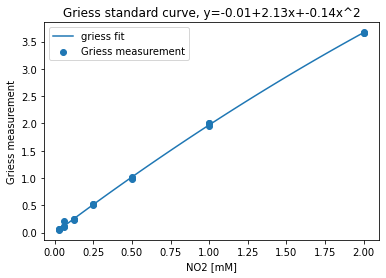

In [10]:
#fit griess assay model using standard curves
std_meta_fn = "/home/kyle/microbial_ecology/pathway_splitting/data_20240914/denit_exp_08042021/standards_metadata.csv"
std_no2_fn = glob.glob("/home/kyle/microbial_ecology/pathway_splitting/data_20240914/denit_exp_08042021/*NO2_standard*")[0]
print(std_no2_fn)
std_no2no3_fn = None
std_no2no3_540_fn = glob.glob("/home/kyle/microbial_ecology/pathway_splitting/data_20240914/denit_exp_08042021/*NO2NO3*540*standard*")[0]
std_no2no3_900_fn = glob.glob("/home/kyle/microbial_ecology/pathway_splitting/data_20240914/denit_exp_08042021/*NO2NO3*900*standard*")[0]

fit = gr.fit_griess(std_meta_fn,std_no2_fn,no2no3_fn=std_no2no3_fn,no2no3_540_fn=std_no2no3_540_fn,no2no3_900_fn=std_no2no3_900_fn)
[[no2_blank,no2no3_blank], g_fit, v_fit] = fit
print(v_fit)
gr.plot_griess_fit(std_meta_fn,std_no2_fn,no2no3_fn=std_no2no3_fn,no2no3_540_fn=std_no2no3_540_fn,no2no3_900_fn=std_no2no3_900_fn)
plt.savefig('griess_standard_curve.png')

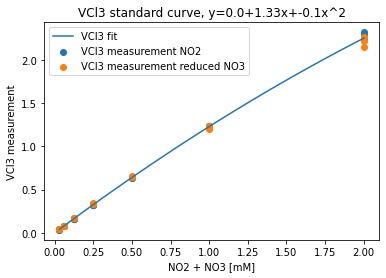

In [11]:
plt.cla()
gr.plot_vcl_fit(std_meta_fn,std_no2_fn,no2no3_fn=std_no2no3_fn,no2no3_540_fn=std_no2no3_540_fn,no2no3_900_fn=std_no2no3_900_fn)
plt.savefig('vcl3_standard_curve.png')

Load time series for two plates and merge into a single data frame.

In [12]:
#manually input time points for measurements (in units of hr)
t = np.array([97,207,330,518,905,1770])/60

#Load plate 1 time series and endpoint OD
meta_fn = "/home/kyle/microbial_ecology/pathway_splitting/data_20240914/denit_exp_08042021/plate1_metadata.csv"
od_fn = glob.glob("/home/kyle/microbial_ecology/pathway_splitting/data_20240914/denit_exp_08042021/*OD_endpoint*plate1*")[0]
no2_fns = sorted(glob.glob("/home/kyle/microbial_ecology/pathway_splitting/data_20240914/denit_exp_08042021/*_NO2_*plate1*"))
no2no3_540_fns = sorted(glob.glob("/home/kyle/microbial_ecology/pathway_splitting/data_20240914/denit_exp_08042021/*_NO2NO3_*540*plate1*"))
no2no3_900_fns = sorted(glob.glob("/home/kyle/microbial_ecology/pathway_splitting/data_20240914/denit_exp_08042021/*_NO2NO3_*900*plate1*"))
[plate1_meta,plate1_od600,plate1_no2,plate1_no3]=gr.load_plate_timeseries(meta_fn,od_fn,no2_fns,no2no3_540_fns,no2no3_900_fns,fit,1)

'''
#load plate 2 time series
meta_fn = "plate2_metadata.csv"
od_fn = glob.glob("*OD_endpoint*plate2*")[0]
no2_fns = sorted(glob.glob("*NO2_plate2*"))
no2no3_540_fns = None
no2no3_900_fns = None
[plate2_meta,plate2_od600,plate2_no2,plate2_no3]=load_plate_timeseries(meta_fn,od_fn,no2_fns,no2no3_540_fns,no2no3_900_fns,fit,2)

#merge plates into a single data_20240914 frame
merged_no2 = plate1_no2.append(plate2_no2)
merged_no3 = plate1_no3.append(plate2_no3)
merged_od600 = plate1_od600.append(plate2_od600)
merged_meta = plate1_meta.append(plate2_meta)
'''
#rename plate 1 info to be consistent with the rest of the code
merged_no2 = plate1_no2
'''
for index, row in merged_no2.iterrows():
    print(row)
print(merged_no2.isnull().values.any())
'''
merged_no3 = plate1_no3
#for index, row in merged_no2.iterrows():
    #print(row)
#print(merged_no3.isnull().values.any())
merged_od600 = plate1_od600
merged_meta = plate1_meta

Compute and apply evaporation correction factors. Evaporation over time causes an increase in apparent concentrations. Make a correction factor for each point in time by measuring the increase in concentrations of blanks.

In [13]:
od_corrfac = 0.84 #this factor scales endpoint ODs to correct for evaporation. Assumes evaporation results in a 1/0.84 increase in apparent OD.
#print(merged_meta)
#print(merged_meta["NO3_0"])
#Compute evaporation corrections separately for each medium condition
idx = (merged_meta["Strain"]=="blank") & (merged_meta["NO3_0"]==2)
no3_2mM_corr = merged_no3.loc[idx].median().values[0]/merged_no3.loc[idx].median().values.reshape(-1,1)
#print('no3 2mM')
#print(no3_2mM_corr)

idx = (merged_meta["Strain"]=="blank") & (merged_meta["NO3_0"]==1)
no3_1mM_corr = merged_no3.loc[idx].median().values[0]/merged_no3.loc[idx].median().values.reshape(-1,1)
#print('no3 1mM')
#print(no3_1mM_corr)

'''
idx = (merged_meta["Strain"]=="blank") & (merged_meta["NO3_0"]==0.5)
no3_05mM_corr = merged_no3.loc[idx].median().values[0]/merged_no3.loc[idx].median().values.reshape(-1,1)
#print('no3 0.5mM')
#print(no3_05mM_corr)
'''

idx = (merged_meta["Strain"]=="blank") & (merged_meta["NO2_0"]==2)
no2_2mM_corr = merged_no2.loc[idx].median().values[0]/merged_no2.loc[idx].median().values.reshape(-1,1)
#print('no2 2mM')
#print(no2_2mM_corr)

idx = (merged_meta["Strain"]=="blank") & (merged_meta["NO2_0"]==1)
no2_1mM_corr = merged_no2.loc[idx].median().values[0]/merged_no2.loc[idx].median().values.reshape(-1,1)
#print('no2 1mM')
#print(no2_1mM_corr)

'''
idx = (merged_meta["Strain"]=="blank") & (merged_meta["NO2_0"]==0.5)
no2_05mM_corr = merged_no2.loc[idx].median().values[0]/merged_no2.loc[idx].median().values.reshape(-1,1)
#print('no2 0.5mM')
#print(no2_05mM_corr)
'''

#apply correction factors
idx = (merged_meta["NO3_0"]==2)

merged_no3.loc[idx] = np.multiply(merged_no3.loc[idx],np.transpose(no3_2mM_corr))
merged_no2.loc[idx] = np.multiply(merged_no2.loc[idx],np.transpose(no2_2mM_corr))
#print('WARNING, USING no3 1 mM correction factor!')
#print(idx)
#print(merged_no2.loc[idx])

idx = (merged_meta["NO3_0"]==1)
merged_no3.loc[idx] = np.multiply(merged_no3.loc[idx],np.transpose(no3_1mM_corr))
merged_no2.loc[idx] = np.multiply(merged_no2.loc[idx],np.transpose(no2_1mM_corr))

'''
idx = (merged_meta["NO3_0"]==0.5)
merged_no3.loc[idx] = np.multiply(merged_no3.loc[idx],np.transpose(no3_05mM_corr))
merged_no2.loc[idx] = np.multiply(merged_no2.loc[idx],np.transpose(no2_05mM_corr))
'''
#print(merged_no2.loc[idx])

idx = (merged_meta["NO2_0"]==2)
merged_no3.loc[idx] = np.multiply(merged_no3.loc[idx],np.transpose(no3_2mM_corr))
merged_no2.loc[idx] = np.multiply(merged_no2.loc[idx],np.transpose(no2_1mM_corr))
#print(merged_no2.loc[idx])
#print('WARNING, USING no2 1 mM correction factor!')

idx = (merged_meta["NO2_0"]==1)
merged_no3.loc[idx] = np.multiply(merged_no3.loc[idx],np.transpose(no3_1mM_corr))
merged_no2.loc[idx] = np.multiply(merged_no2.loc[idx],np.transpose(no2_1mM_corr))
#print(merged_no2.loc[idx])

'''
idx = (merged_meta["NO2_0"]==0.5)
merged_no3.loc[idx] = np.multiply(merged_no3.loc[idx],np.transpose(no3_05mM_corr))
merged_no2.loc[idx] = np.multiply(merged_no2.loc[idx],np.transpose(no2_05mM_corr))
'''


'\nidx = (merged_meta["NO2_0"]==0.5)\nmerged_no3.loc[idx] = np.multiply(merged_no3.loc[idx],np.transpose(no3_05mM_corr))\nmerged_no2.loc[idx] = np.multiply(merged_no2.loc[idx],np.transpose(no2_05mM_corr))\n'

Format data into experiments object. Use the "merged_meta" dataframe to index.

In [19]:
#List of unique strains
strains = np.setdiff1d(np.unique(merged_meta["ID"]),['blank'])
all_experiments = []

#For each strain, identify wells corresponding to each experimental condition and put into experiments object
for j in range(0,len(strains)):
    print(j)
    phen = merged_meta['Phenotype'].iloc[np.where(merged_meta['ID'] == strains[j])[0][0]]
    
    #"cond" is a list of experimental conditions for each strain, by phenotype.
    #Format is an Mx3 array where the first column is OD_0, second column is A_0, and third column is I_0.
    #M is the number of experimental conditions
    if phen == 'Nar/Nir':
        cond = np.array([[0.01,2,0],[0.01,1,0],[0.001,2,0],[0.01,0,2],[0.01,0,1],[0.001,0,2]])
    elif phen == 'Nar':
        cond = np.array([[0.01,2,0],[0.01,1,0],[0.001,2,0]])
    elif phen == 'Nir':
        cond = np.array([[0.01,0,2],[0.01,0,1],[0.001,0,2]])

    #load data_20240914 into a list of experiment objects
    experiments = []
    for i in range(0,cond.shape[0]):
        print('i is ' + str(i))
        print(cond[i,0])
        print(cond[i,1])
        print(cond[i,2])
        idx = ((merged_meta["ID"]==strains[j])) & (merged_meta["OD600_0"]==cond[i,0]) & (merged_meta["NO3_0"]==cond[i,1]) & (merged_meta["NO2_0"]==cond[i,2])
        blank_idx = merged_meta["Strain"]=="blank"
        
        A0 = cond[i,1]
        A = merged_no3.loc[idx].values
        I0 = cond[i,2]
        I = merged_no2.loc[idx].values
        print(I0)
        print(A0)
        print(I)
        
        Nend = np.ravel((merged_od600.loc[idx].values - np.nanmedian(merged_od600.loc[blank_idx].values))*od_corrfac)
        print(merged_meta['OD600_0_true'].loc[idx])
        N0 = merged_meta['OD600_0_true'].loc[idx][0]
        
        experiments.append(dn.experiment(strains[j],phen,N0,Nend,A0,A,I0,I,t))
    
    all_experiments.append(experiments)
pickle_out = open("/home/kyle/microbial_ecology/pathway_splitting/data_20240914/denit_exp_08042021/phenotypes_08042021.pkl","wb")
pickle.dump(all_experiments, pickle_out)
pickle_out.close()

0
i is 0
0.01
2.0
0.0
0.0
2.0
[[0.04587187 0.06302307 0.07522495 0.1250123  0.55028412 0.03201033]
 [0.05533803 0.07953965 0.10074517 0.16760268 0.75073292 0.03330628]]
p1_A01    0.010074
p1_A02    0.010074
Name: OD600_0_true, dtype: object
i is 1
0.01
1.0
0.0
0.0
1.0
[[0.06576501 0.12058814 0.14539986 0.24088268 0.83142144 0.0287762 ]
 [0.04823726 0.08688005 0.10428598 0.18335491 0.77424937 0.0287762 ]]
p1_A03    0.010074
p1_A04    0.010074
Name: OD600_0_true, dtype: object
i is 2
0.001
2.0
0.0
0.0
2.0
[[0.03641795 0.03902321 0.04039841 0.04431719 0.10923967 0.72533768]
 [0.03500092 0.03996288 0.03899005 0.04478374 0.13199001 0.92078128]]
p1_A05    0.00138
p1_A06    0.00138
Name: OD600_0_true, dtype: object
i is 3
0.01
0.0
2.0
2.0
0.0
[[1.74708134 1.8034014  1.79119936 1.76747802 1.71764794 1.72915534]
 [1.74831452 1.03085433 1.72583556 1.83016731 1.71879619 1.77813471]]
p1_A07    0.010074
p1_A08    0.010074
Name: OD600_0_true, dtype: object
i is 4
0.01
0.0
1.0
1.0
0.0
[[0.9159611  1.